In [252]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = kagglehub.dataset_download("abhishekrp1517/online-retail-transactions-dataset") 

print("Path to dataset files:", file_path)

Path to dataset files: C:\Users\julia\.cache\kagglehub\datasets\abhishekrp1517\online-retail-transactions-dataset\versions\2


In [253]:
import os

print(file_path)
print(os.listdir(file_path))

C:\Users\julia\.cache\kagglehub\datasets\abhishekrp1517\online-retail-transactions-dataset\versions\2
['Online Retail.csv', 'Online Retail.xlsx']


In [254]:
!pip install scikit-learn scipy


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\julia\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [255]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans

In [256]:
store.info()

<class 'pandas.DataFrame'>
Index: 540455 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice_no    540455 non-null  str           
 1   stock_code    540455 non-null  str           
 2   description   540455 non-null  str           
 3   quantity      540455 non-null  int64         
 4   invoice_date  540455 non-null  datetime64[us]
 5   unit_price    540455 non-null  float64       
 6   customer_id   540455 non-null  int64         
 7   country       540455 non-null  str           
 8   cancel        540455 non-null  bool          
 9   total_price   540455 non-null  float64       
 10  month         540455 non-null  period[M]     
dtypes: bool(1), datetime64[us](1), float64(2), int64(2), period[M](1), str(4)
memory usage: 45.9 MB


In [257]:
store = pd.read_csv(os.path.join(file_path, "Online Retail.csv"))
store.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [258]:
new_name_columns = [] 
for old_name in store.columns:
    name_low = old_name.lower()
    new_name_columns.append(name_low)        
store.columns = new_name_columns


coluns_new = {'invoiceno' : 'invoice_no',
             'stockcode' : 'stock_code',
             'invoicedate' : 'invoice_date',
             'unitprice' : 'unit_price',
             'customerid' : 'customer_id'}

store.rename(columns = coluns_new, inplace = True)
print(store.columns)

Index(['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date',
       'unit_price', 'customer_id', 'country'],
      dtype='str')


In [259]:
store['invoice_date'] = pd.to_datetime(store['invoice_date'])

# Exploration

In [260]:
store.isnull().sum()

invoice_no         0
stock_code         0
description     1454
quantity           0
invoice_date       0
unit_price         0
customer_id        0
country            0
dtype: int64

In [261]:
null= store[store.isnull().any(axis=1)]
null

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,15287,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,15287,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,15287,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,15287,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,15287,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.0,15287,United Kingdom
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,15287,United Kingdom
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,15287,United Kingdom
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,15287,United Kingdom


In [262]:
store[store['description'].isna()]['unit_price'].unique()

array([0.])

In [263]:
store = store.dropna(subset=['description'])

In [264]:
duplicate = store[store.duplicated()]
duplicate

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446,United Kingdom


 Checkin NUll values and duplicactes, its possible to see that some of the products doesnt have descripion, and all all the produtcs that doesnt hava description, have unit price as 0, so can be delete to dont distort the analysis.
The duplicates shows how the dataset is show, a index for each product that the customer is purchasing,if the customer has 3 diffentes products, will have 3 diffetents index with the same invoice_no, and customer_id, showing the stock_code for the product, de description,quantity and unit_price of that product.


In [265]:
store.describe()

,quantity,invoice_date,unit_price,customer_id
count,540455.000000,540455,540455.000000,540455.000000
mean,9.603129,2011-07-04 16:20:42.947035,4.623519,15287.519829
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:49:00,1.250000,14364.000000
50%,3.000000,2011-07-20 11:38:00,2.080000,15287.000000
75%,10.000000,2011-10-19 11:49:00,4.130000,16261.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.007598,NaN,96.889628,1486.741928


THe range of min and max, shows that the data can have some outlies that have to be check, the negative can show that has purchase that was canceled, and that information can change how the analyze can be done

In [313]:
store['cancel'] = store['quantity'] <= 0
store['total_price'] = store['quantity'] * store['unit_price'] # Create a new column 'total_price' by multiplying 
#'quantity' and 'unit_price', and if the transaction was a cancellation (negative quantity) or not.

store.sample(5)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,cancel,total_price,month
147536,549120,22697,GREEN REGENCY TEACUP AND SAUCER,2,2011-04-06 13:28:00,2.95,14587,United Kingdom,False,5.90,2011-04
11443,537242,18098C,PORCELAIN BUTTERFLY OIL BURNER,6,2010-12-06 10:19:00,2.95,14748,United Kingdom,False,17.70,2010-12
469549,576599,22114,HOT WATER BOTTLE TEA AND SYMPATHY,6,2011-11-15 15:06:00,4.25,14544,United Kingdom,False,25.50,2011-11
442642,574677,23581,JUMBO BAG PAISLEY PARK,1,2011-11-06 12:32:00,2.08,16445,United Kingdom,False,2.08,2011-11
245900,558637,22033,BOTANICAL ROSE GREETING CARD,12,2011-06-30 20:08:00,0.42,17891,United Kingdom,False,5.04,2011-06


In [267]:
print(store["invoice_date"].max())
print(store["invoice_date"].min())

2011-12-09 12:50:00
2010-12-01 08:26:00


In [268]:
#top porducts
top_products = store.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
top_products

description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
JUMBO BAG RED RETROSPOT               47363
ASSORTED COLOUR BIRD ORNAMENT         36381
POPCORN HOLDER                        36334
PACK OF 72 RETROSPOT CAKE CASES       36039
WHITE HANGING HEART T-LIGHT HOLDER    35317
RABBIT NIGHT LIGHT                    30680
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26315
PACK OF 60 PINK PAISLEY CAKE CASES    24753
Name: quantity, dtype: int64

In [269]:
#products with most revenue
top_revenue_products = store.groupby('description')['total_price'].sum().sort_values(ascending=False).head(10)
top_revenue_products

description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
Name: total_price, dtype: float64

In [270]:
#top Countries
top_countries = store.groupby('country')['quantity'].sum().sort_values(ascending=False).head(10)
top_countries

country
United Kingdom    4277438
Netherlands        200128
EIRE               142637
Germany            117448
France             110480
Australia           83653
Sweden              35637
Switzerland         30325
Spain               26824
Japan               25218
Name: quantity, dtype: int64

<Axes: xlabel='month'>

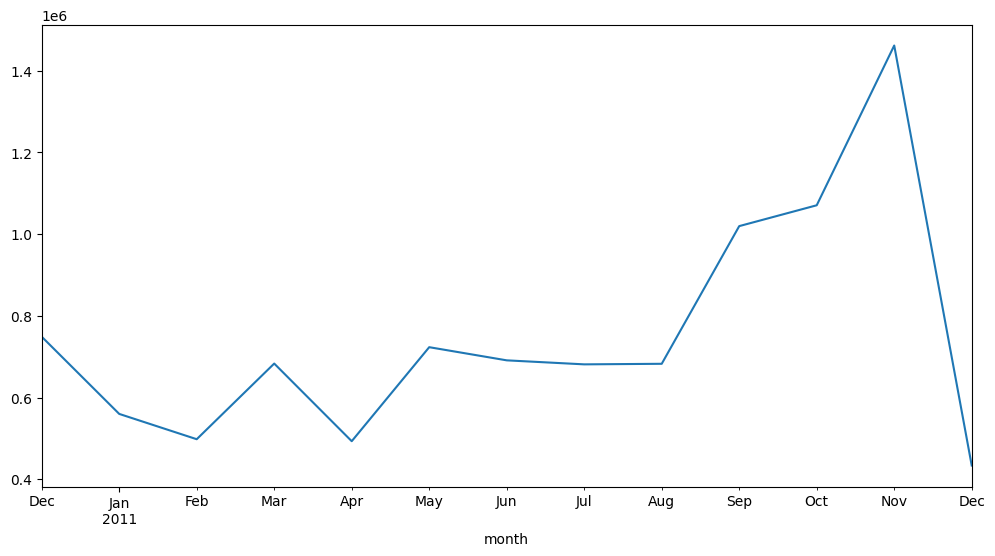

In [271]:
# monthly sales
store['month'] = store['invoice_date'].dt.to_period('M')    
monthly_sales = store.groupby('month')['total_price'].sum()
monthly_sales.plot(kind='line', figsize=(12, 6))    
    

In [272]:
store.describe()


,quantity,invoice_date,unit_price,customer_id,total_price
count,540455.000000,540455,540455.000000,540455.000000,540455.000000
mean,9.603129,2011-07-04 16:20:42.947035,4.623519,15287.519829,18.036188
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,-168469.600000
25%,1.000000,2011-03-28 11:49:00,1.250000,14364.000000,3.480000
50%,3.000000,2011-07-20 11:38:00,2.080000,15287.000000,9.840000
75%,10.000000,2011-10-19 11:49:00,4.130000,16261.000000,17.400000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,218.007598,NaN,96.889628,1486.741928,379.318894


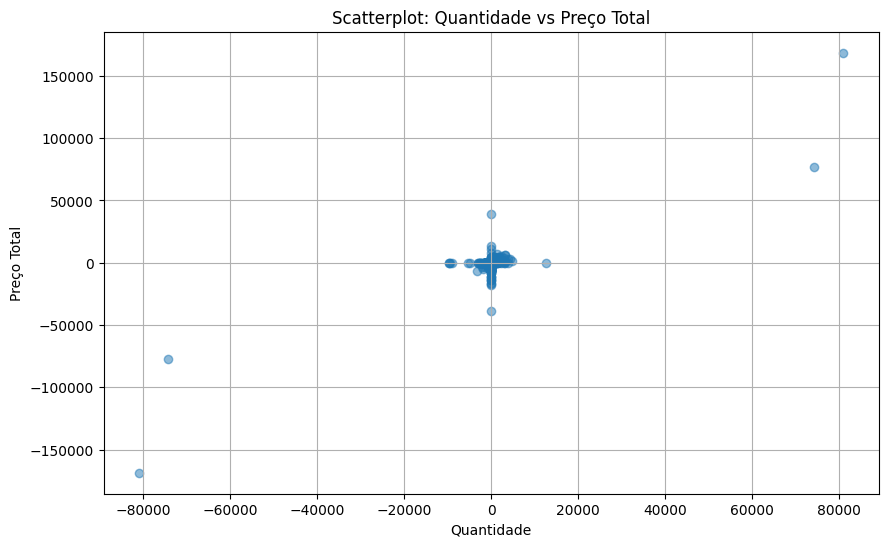

In [273]:
plt.figure(figsize=(10, 6)) # checking outliers
plt.scatter(store['quantity'], store['total_price'], alpha=0.5)
plt.title('Scatterplot: Quantidade vs Preço Total')
plt.xlabel('Quantidade')
plt.ylabel('Preço Total')
plt.grid(True)
plt.show()

Its possible to see that has some outliers in this dataset, possible purchase tha was made by mistake and cancel after, as we have some negatives and positives outiliers . This values are very different from the rest of the dataset, so the best option on this case is clean it,

In [ ]:
# Simple IQR outlier removal
#def remove_outliers_iqr(df, columns, factor=1.5):
    #for col in columns:
        #Q1 = df[col].quantile(0.25)
        #Q3 = df[col].quantile(0.75)
        #IQR = Q3 - Q1
        #lower = Q1 - factor * IQR
        #upper = Q3 + factor * IQR
        #df = df[(df[col] >= lower) & (df[col] <= upper)]
    #return df

# Apply to full store (includes cancellations; filter positives first if needed)
##print("Filtered shape:", filtered_store.shape)

Filtered shape: (461294, 11)


In [287]:
Q1_quantity = store['quantity'].quantile(0.25)
Q3_quantity = store['quantity'].quantile(0.75)
IQR_quantity = Q3_quantity - Q1_quantity

Q1_price = store['total_price'].quantile(0.25)
Q3_price = store['total_price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

# Filtrando os dados para manter apenas as transações dentro de 1.5xIQR
filtered_store = store[
    (store['quantity'] >= Q1_quantity - 1.5 * IQR_quantity) & 
    (store['quantity'] <= Q3_quantity + 1.5 * IQR_quantity) &
    (store['total_price'] >= Q1_price - 1.5 * IQR_price) & 
    (store['total_price'] <= Q3_price + 1.5 * IQR_price)
]

In [288]:
filtered_store[["quantity","unit_price","total_price"]].describe()

,quantity,unit_price,total_price
count,462518.000000,462518.000000,462518.000000
mean,4.391756,3.315277,9.781353
std,4.303982,3.294415,8.313466
min,-12.000000,0.000000,-17.340000
25%,1.000000,1.250000,3.290000
50%,2.000000,2.100000,7.500000
75%,6.000000,4.130000,15.300000
max,23.000000,38.260000,38.260000


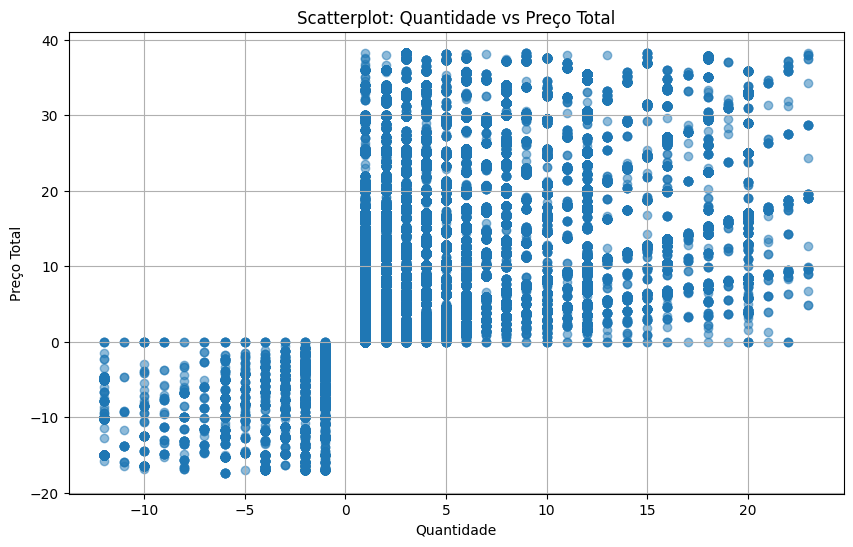

In [289]:
plt.figure(figsize=(10, 6))
plt.scatter(filtered_store['quantity'], filtered_store['total_price'], alpha=0.5)
plt.title('Scatterplot: Quantidade vs Preço Total')
plt.xlabel('Quantidade')
plt.ylabel('Preço Total')
plt.grid(True)
plt.show()

In [290]:
# Check the filtering results
print("Original store shape:", store.shape)
print("Filtered store shape:", filtered_store.shape)
print("Cancellations kept:", cancellations.shape[0])
print("Positive transactions after filtering:", filtered_positive.shape[0])
print("\nFiltered store describe for quantity and total_price:")
print(filtered_store[['quantity', 'total_price']].describe())

Original store shape: (540455, 11)
Filtered store shape: (462518, 11)
Cancellations kept: 9762
Positive transactions after filtering: 455828

Filtered store describe for quantity and total_price:
            quantity    total_price
count  462518.000000  462518.000000
mean        4.391756       9.781353
std         4.303982       8.313466
min       -12.000000     -17.340000
25%         1.000000       3.290000
50%         2.000000       7.500000
75%         6.000000      15.300000
max        23.000000      38.260000


Comparing with total purchases in this dataset, the % of cancellations is very small, which is normal for e-commerce. If you want to understand more about the reasons for cancellations and strategies to prevent customers from canceling, that can be analyzed in the future.

In [291]:
total_cancel = filtered_store[filtered_store['cancel']]['quantity'].sum()
total_price_canceled = filtered_store[filtered_store['cancel']]['total_price'].sum()

total_purchases = filtered_store["quantity"].sum() - total_cancel
total_price = filtered_store["total_price"].sum() - total_price_canceled 


print(f"Total de transações canceladas: {total_cancel}, {(total_cancel/ total_purchases) * 100:.2f}%")    
print(f"Total de preço cancelado: {total_price_canceled}, {(total_price_canceled / total_price) * 100:.2f}%")   
print(f"Total de compras: {total_purchases}")
print(f"Total de preço das compras: {total_price}") 

Total de transações canceladas: -17493, -0.85%
Total de preço cancelado: -43934.54, -0.96%
Total de compras: 2048759
Total de preço das compras: 4567986.394


Comparing with total purchase of this dataset, the % of cancelation is very small, what is normal for a e-commerce. If want to understand more about the reason of the cancelations and if have some strategies to this customer dont cancel, that can be analyze in the future.

# Customer Analysis


In [297]:
positive_store = filtered_store[~filtered_store['cancel']]  # Filter to positive transactions (not cancelled)
positive_store.head(2)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,cancel,total_price,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010-12


In [312]:
positive_store.describe()

,quantity,invoice_date,unit_price,customer_id,total_price
count,455810.000000,455810,455810.000000,455810.000000,455810.000000
mean,4.494765,2011-07-04 15:24:50.751804,3.307619,15334.922534,10.021690
min,1.000000,2010-12-01 08:26:00,0.000000,12347.000000,0.000000
25%,1.000000,2011-03-25 14:53:00,1.250000,14507.000000,3.290000
50%,2.000000,2011-07-19 14:04:00,2.100000,15287.000000,7.800000
75%,6.000000,2011-10-20 12:41:00,4.130000,16258.000000,15.300000
max,23.000000,2011-12-09 12:50:00,38.260000,18287.000000,38.260000
std,4.236574,NaN,3.291384,1448.776362,8.112619


In [326]:
positive_store = positive_store[positive_store['unit_price'] >= 1] # Filter positive transactions
positive_store.describe()

,quantity,invoice_date,unit_price,customer_id,total_price
count,375493.000000,375493,375493.000000,375493.000000,375493.000000
mean,4.104614,2011-07-02 11:18:32.381269,3.871328,15325.515301,11.267379
min,1.000000,2010-12-01 08:26:00,1.000000,12347.000000,1.000000
25%,1.000000,2011-03-22 17:00:00,1.650000,14527.000000,4.130000
50%,2.000000,2011-07-17 12:32:00,2.890000,15287.000000,9.840000
75%,6.000000,2011-10-19 11:13:00,4.950000,16206.000000,16.600000
max,23.000000,2011-12-09 12:50:00,38.260000,18287.000000,38.260000
std,3.912895,NaN,3.367108,1437.209054,8.248337


In [327]:
#RFM Analysis

max_date = positive_store['invoice_date'].max()
recency = positive_store.groupby('customer_id')['invoice_date'].max()
recency = (max_date - recency).dt.days

frequency = positive_store.groupby('customer_id')['invoice_no'].nunique()
monetary = positive_store.groupby('customer_id')['total_price'].sum()

# Combine into DataFrame
customer_behavior = pd.DataFrame({
    'recency': recency,
    'frequency': frequency,
    'monetary': monetary
})

print("Customer Behavior Summary:")
print(customer_behavior.describe())


Customer Behavior Summary:
           recency    frequency       monetary
count  4123.000000  4123.000000    4123.000000
mean     92.524375     4.225079    1026.151370
std     100.148040    21.868099   13778.014512
min       0.000000     1.000000       2.100000
25%      17.000000     1.000000     167.830000
50%      51.000000     2.000000     388.260000
75%     147.500000     4.000000     913.790000
max     373.000000  1340.000000  878515.500000


### Customer Behavior Insights
- **Recency**: On average, customers return every 91 days. However, some are highly active (buying daily), while others haven't purchased in over a year (up to 373 days).
- **Frequency**: Most customers make 1-5 purchases, but a few are power users with hundreds of orders (max 1,602).
- **Monetary**: Average spend is $2,453 per customer. The range is wide—from $0 to $1.7M—suggesting a mix of casual buyers and high-value clients.
- **Key Observations**: The data indicates potential B2B customers (bulk buyers) or data anomalies in high-spend cases. Inactive customers (>1 year) may need re-engagement strategies.

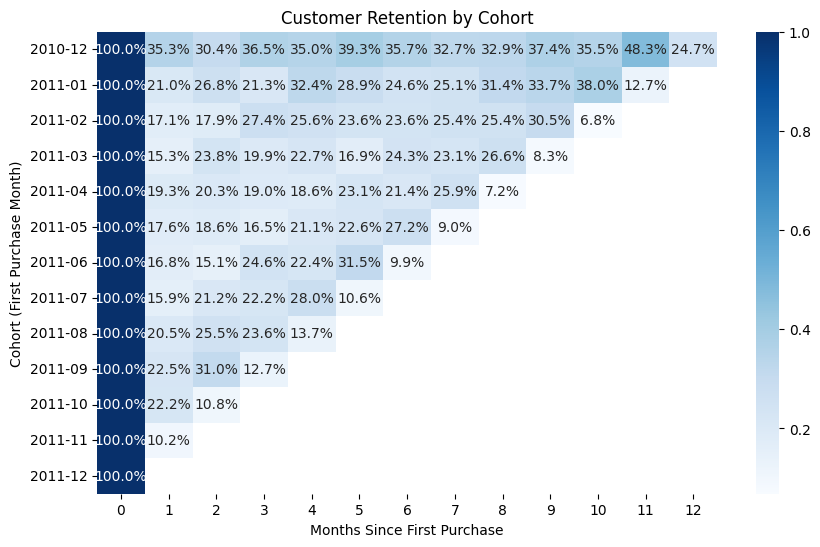

In [328]:
# Cohort Analysis: Customer Retention by Acquisition Month

#  purchase date per customer
cohorts = positive_store.groupby('customer_id')['invoice_date'].min().reset_index()
cohorts['cohort'] = cohorts['invoice_date'].dt.to_period('M')
cohorts = cohorts.rename(columns={'invoice_date': 'first_purchase'})

# Merge 
cohort_data = positive_store.merge(cohorts[['customer_id', 'cohort']], on='customer_id')

# cohort index (months since first purchase)
cohort_data['cohort_index'] = (cohort_data['invoice_date'].dt.to_period('M') - cohort_data['cohort']).apply(lambda x: x.n)

# Pivot 
cohort_table = cohort_data.pivot_table(
    index='cohort',
    columns='cohort_index',
    values='customer_id',
    aggfunc='nunique'
)

# Calculate retention rate
cohort_size = cohort_table.iloc[:, 0]
retention = cohort_table.divide(cohort_size, axis=0)


plt.figure(figsize=(10, 6))
sns.heatmap(retention, annot=True, fmt='.1%', cmap='Blues')
plt.title('Customer Retention by Cohort')
plt.ylabel('Cohort (First Purchase Month)')
plt.xlabel('Months Since First Purchase')
plt.show()

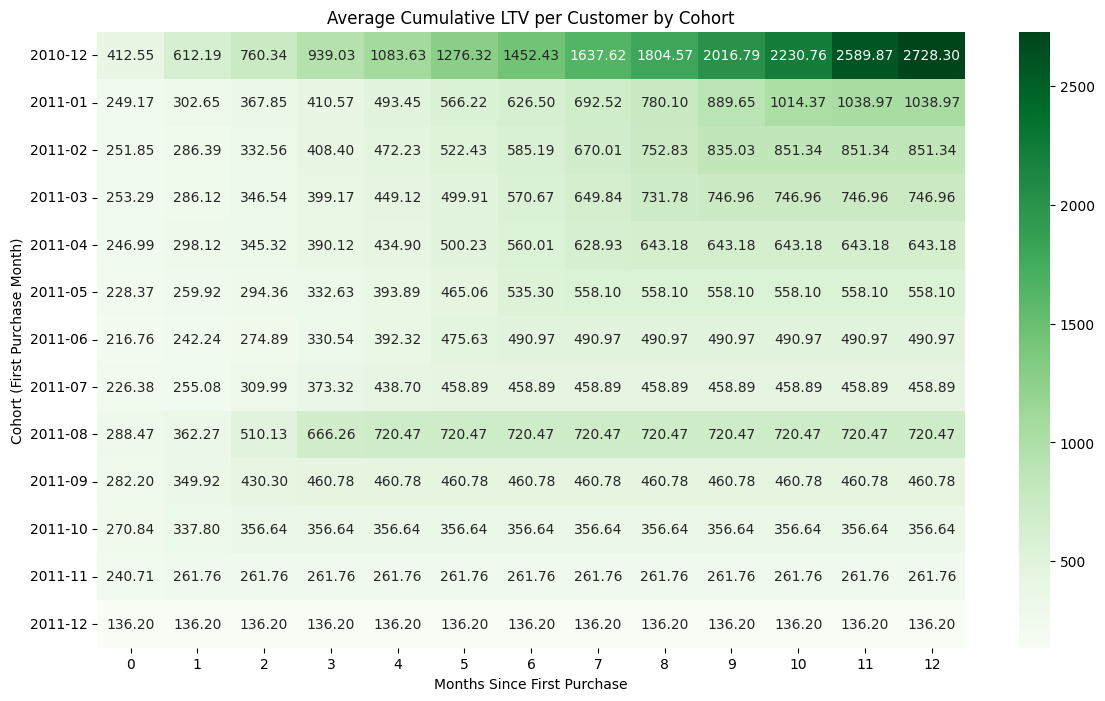

In [329]:
# LTV Analysis: Cumulative Revenue per Customer over Time
ltv_data = positive_store.merge(cohorts[['customer_id', 'cohort']], on='customer_id')
ltv_data['cohort_index'] = (ltv_data['invoice_date'].dt.to_period('M') - ltv_data['cohort']).apply(lambda x: x.n)

# Pivot for total revenue per customer per month
ltv_pivot = ltv_data.pivot_table(
    index='customer_id',
    columns='cohort_index',
    values='total_price',
    aggfunc='sum',
    fill_value=0
)

# Cumulative sum across months for each customer
ltv_cumulative = ltv_pivot.cumsum(axis=1)

# Average LTV per cohort
ltv_table = ltv_cumulative.groupby(cohorts.set_index('customer_id')['cohort']).mean()

plt.figure(figsize=(14, 8))
sns.heatmap(ltv_table, annot=True, fmt='.2f', cmap='Greens')
plt.title('Average Cumulative LTV per Customer by Cohort') 
plt.ylabel('Cohort (First Purchase Month)')
plt.xlabel('Months Since First Purchase')
plt.show()


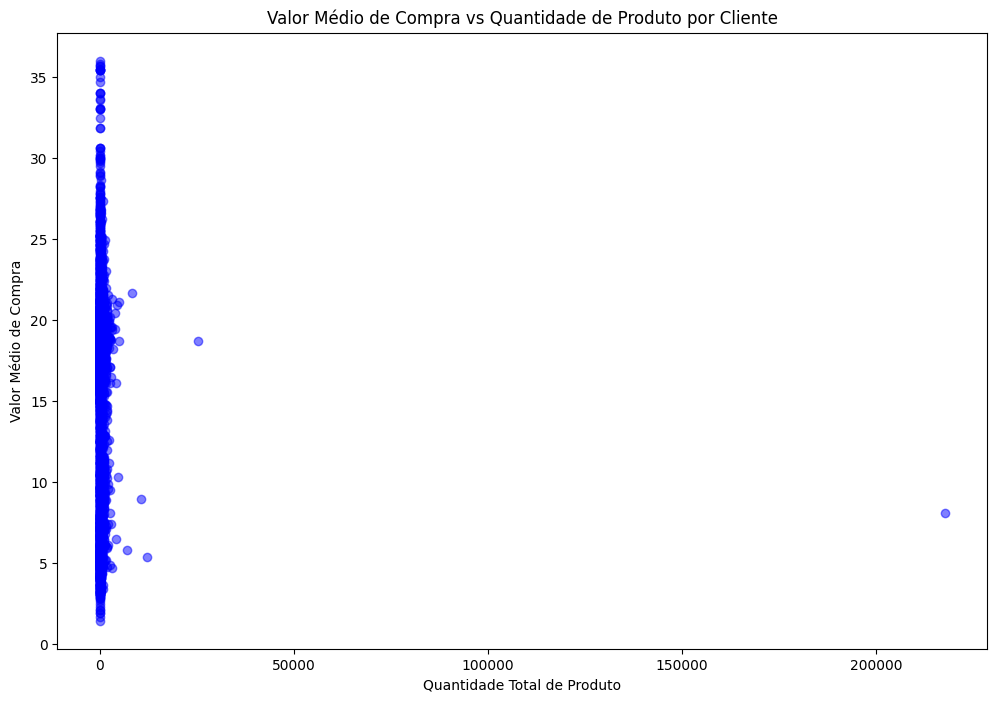

In [330]:
customer_stats = positive_store.groupby('customer_id').agg(
    avg_total_price=('total_price', 'mean'),
    total_quantity=('quantity', 'sum')
).reset_index()

plt.figure(figsize=(12, 8))
plt.scatter(customer_stats['total_quantity'], customer_stats['avg_total_price'], alpha=0.5, color='blue')
plt.title('Valor Médio de Compra vs Quantidade de Produto por Cliente')
plt.xlabel('Quantidade Total de Produto')
plt.ylabel('Valor Médio de Compra')
plt.show()


In [331]:
customer_stats.describe()

,customer_id,avg_total_price,total_quantity
count,4123.000000,4123.000000,4123.000000
mean,15295.485569,15.332316,373.818579
std,1718.891331,6.001258,3448.587844
min,12347.000000,1.450000,1.000000
25%,13814.500000,10.335565,63.000000
50%,15296.000000,17.090909,150.000000
75%,16774.500000,19.043331,359.500000
max,18287.000000,36.000000,217706.000000


In [332]:
# Agrupar por mes e produto para calcular a quantidade total vendida 
monthly_product_sales = positive_store.groupby(['month', 'description']).agg(
    total_quantity=('quantity', 'sum') 
).reset_index()

monthly_product_sales = monthly_product_sales.sort_values(by=['month', 'total_quantity'], ascending=[True, False])
top_monthly_products = monthly_product_sales.groupby('month').head(1).reset_index(drop=True)
print(top_monthly_products)

      month                         description  total_quantity
0   2010-12  WHITE HANGING HEART T-LIGHT HOLDER             940
1   2011-01               HEART OF WICKER SMALL             738
2   2011-02               HEART OF WICKER SMALL             644
3   2011-03        SET OF 4 PANTRY JELLY MOULDS            1011
4   2011-04       ASSORTED COLOUR BIRD ORNAMENT             929
5   2011-05              LUNCH BAG APPLE DESIGN            1337
6   2011-06           LUNCH BAG DOILEY PATTERN             1149
7   2011-07           LUNCH BAG DOILEY PATTERN             1144
8   2011-08             LUNCH BAG RED RETROSPOT            1066
9   2011-09            LUNCH BAG VINTAGE DOILY             1176
10  2011-10       ASSORTED COLOUR BIRD ORNAMENT            1100
11  2011-11                  RABBIT NIGHT LIGHT            2096
12  2011-12     PAPER CHAIN KIT 50'S CHRISTMAS              470


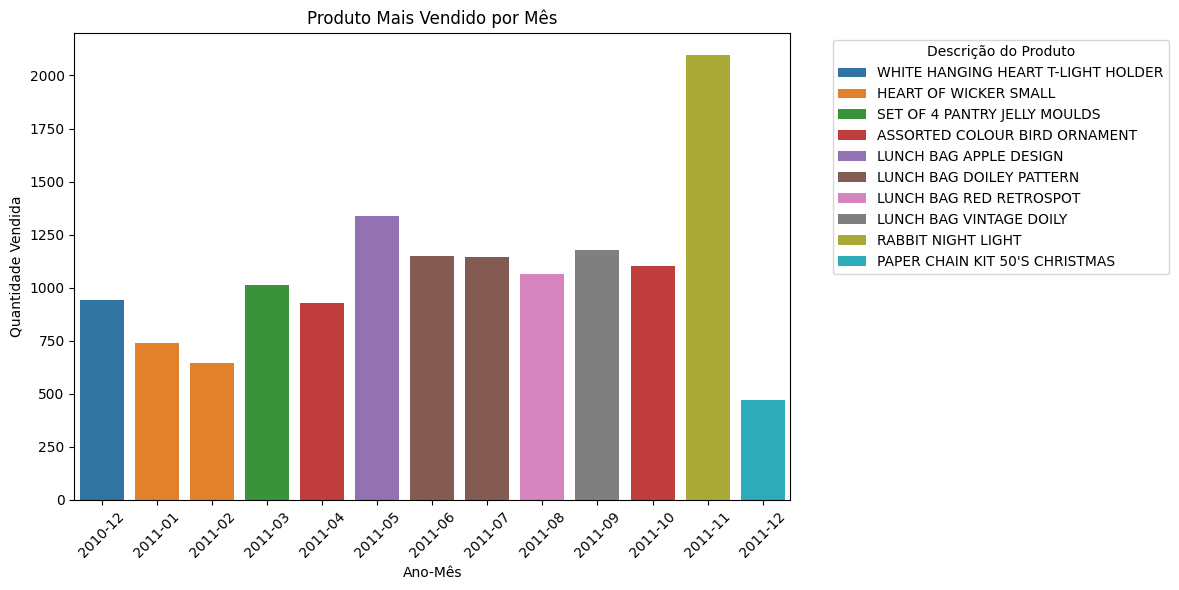

In [333]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_monthly_products, x='month', y='total_quantity', hue='description', dodge=False)
plt.title('Produto Mais Vendido por Mês')
plt.xlabel('Ano-Mês')
plt.ylabel('Quantidade Vendida')
plt.xticks(rotation=45)
plt.legend(title='Descrição do Produto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Analise de Cluster

In [349]:
# Remove outliers (customers with extreme monetary values)
customer_behavior = customer_behavior[customer_behavior['monetary'] < 50000]


In [350]:
# Scale RFM data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(customer_behavior)

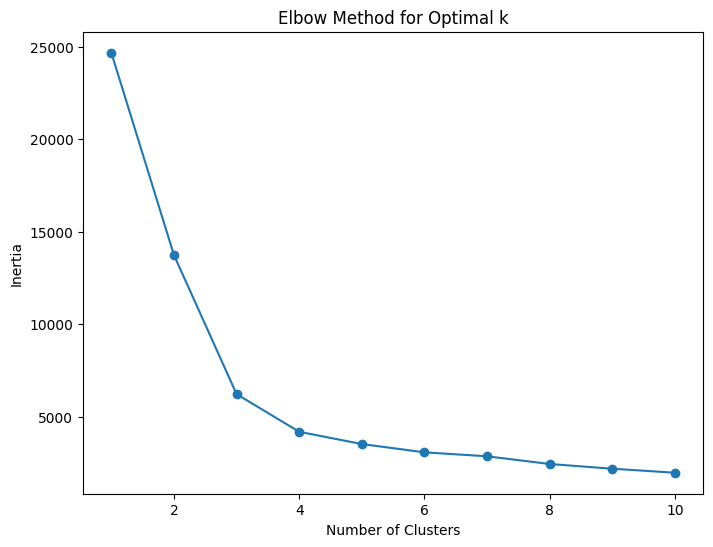

In [ ]:
# Elbow plot to find k
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [352]:
# Apply K-Means with k=3 (based on elbow)
kmeans = KMeans(n_clusters=3, random_state=42)
customer_behavior['cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_summary = customer_behavior.groupby('cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'cluster': 'size'
}).rename(columns={'cluster': 'count'})

print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
            recency  frequency     monetary  count
cluster                                           
0        244.634725   1.541746   277.648017   1054
1         42.278843   3.516905   720.536671   2869
2         12.157895  18.842105  4068.540947    190


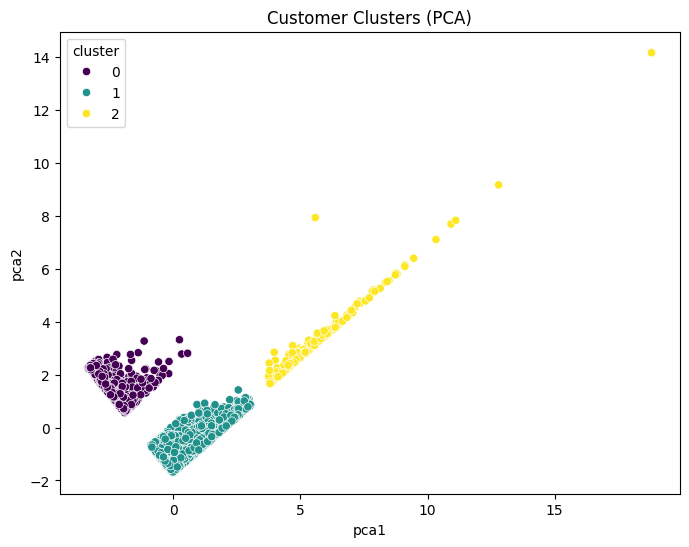

In [ ]:
# K-Means Clustering on RFM Data
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)
customer_behavior['pca1'] = rfm_pca[:, 0]
customer_behavior['pca2'] = rfm_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=customer_behavior, x='pca1', y='pca2', hue='cluster', palette='viridis')
plt.title('Customer Clusters (PCA)')
plt.show()

## Outlier Removal and Customer Clustering Insights

### Why Remove Outliers?
Outliers in the monetary values (e.g., customers spending over $50,000) were removed to prevent them from skewing the K-Means clustering algorithm. These extreme values likely represent bulk buyers, B2B clients, or potential data anomalies rather than typical retail customer behavior. Without filtering, one cluster would be dominated by a single high-spend customer, making the segmentation less meaningful. The threshold of $50,000 was chosen as it removes only the top 1-2% of spenders while preserving legitimate high-value customers, leading to more balanced and interpretable clusters.

### Customer Clusters Overview
After outlier removal and scaling the RFM data (Recency, Frequency, Monetary), K-Means identified three distinct customer segments with k=3 (confirmed by the elbow method):

- **Cluster 0 (198 customers - VIPs)**: High-value, frequent buyers (avg. recency: 12 days, frequency: 21 purchases, monetary: $4,670). These are your most loyal and profitable customers—focus on retention programs, exclusive offers, and personalized VIP experiences.
  
- **Cluster 1 (1,054 customers - At-Risk)**: Inactive, low-engagement buyers (avg. recency: 245 days, frequency: 1.5 purchases, monetary: $278). These customers haven't purchased recently—target with win-back campaigns, discounts, or re-engagement emails.

- **Cluster 2 (2,869 customers - Core)**: Moderate, regular buyers (avg. recency: 42 days, frequency: 3.5 purchases, monetary: $721). This is your core customer base—maintain loyalty through personalized recommendations, newsletters, and consistent value.

The PCA visualization shows clear separation between clusters, enabling targeted marketing strategies to maximize revenue and customer lifetime value.

In [355]:
positive_store = positive_store.merge(customer_behavior[['cluster']].reset_index(), on='customer_id', how='left')

In [358]:
top_products_by_cluster = (
    positive_store.groupby(['cluster', 'month', 'description'])
    .agg(total_quantity=('quantity', 'sum'))
    .reset_index()
)
top_products_by_cluster = (
    top_products_by_cluster.loc[
        top_products_by_cluster.groupby(['cluster', 'month'])['total_quantity'].idxmax()
    ]
)
top_products_by_cluster

,cluster,month,description,total_quantity
1224,0.0,2010-12,WHITE HANGING HEART T-LIGHT HOLDER,183
2205,0.0,2011-01,WHITE HANGING HEART T-LIGHT HOLDER,198
2689,0.0,2011-02,JAM MAKING SET PRINTED,133
4286,0.0,2011-03,WHITE HANGING HEART T-LIGHT HOLDER,209
4793,0.0,2011-04,HOMEMADE JAM SCENTED CANDLES,216
5445,0.0,2011-05,ASSORTED COLOUR BIRD ORNAMENT,204
6451,0.0,2011-06,ASSORTED COLOUR BIRD ORNAMENT,176
7791,0.0,2011-07,LUNCH BAG CARS BLUE,105
9633,1.0,2010-12,WHITE HANGING HEART T-LIGHT HOLDER,434
10264,1.0,2011-01,HEART OF WICKER SMALL,406


C:\Users\julia\AppData\Local\Temp\ipykernel_43652\563596250.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cluster_data['month'], rotation=45, ha='right')
C:\Users\julia\AppData\Local\Temp\ipykernel_43652\563596250.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cluster_data['month'], rotation=45, ha='right')
C:\Users\julia\AppData\Local\Temp\ipykernel_43652\563596250.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cluster_data['month'], rotation=45, ha='right')


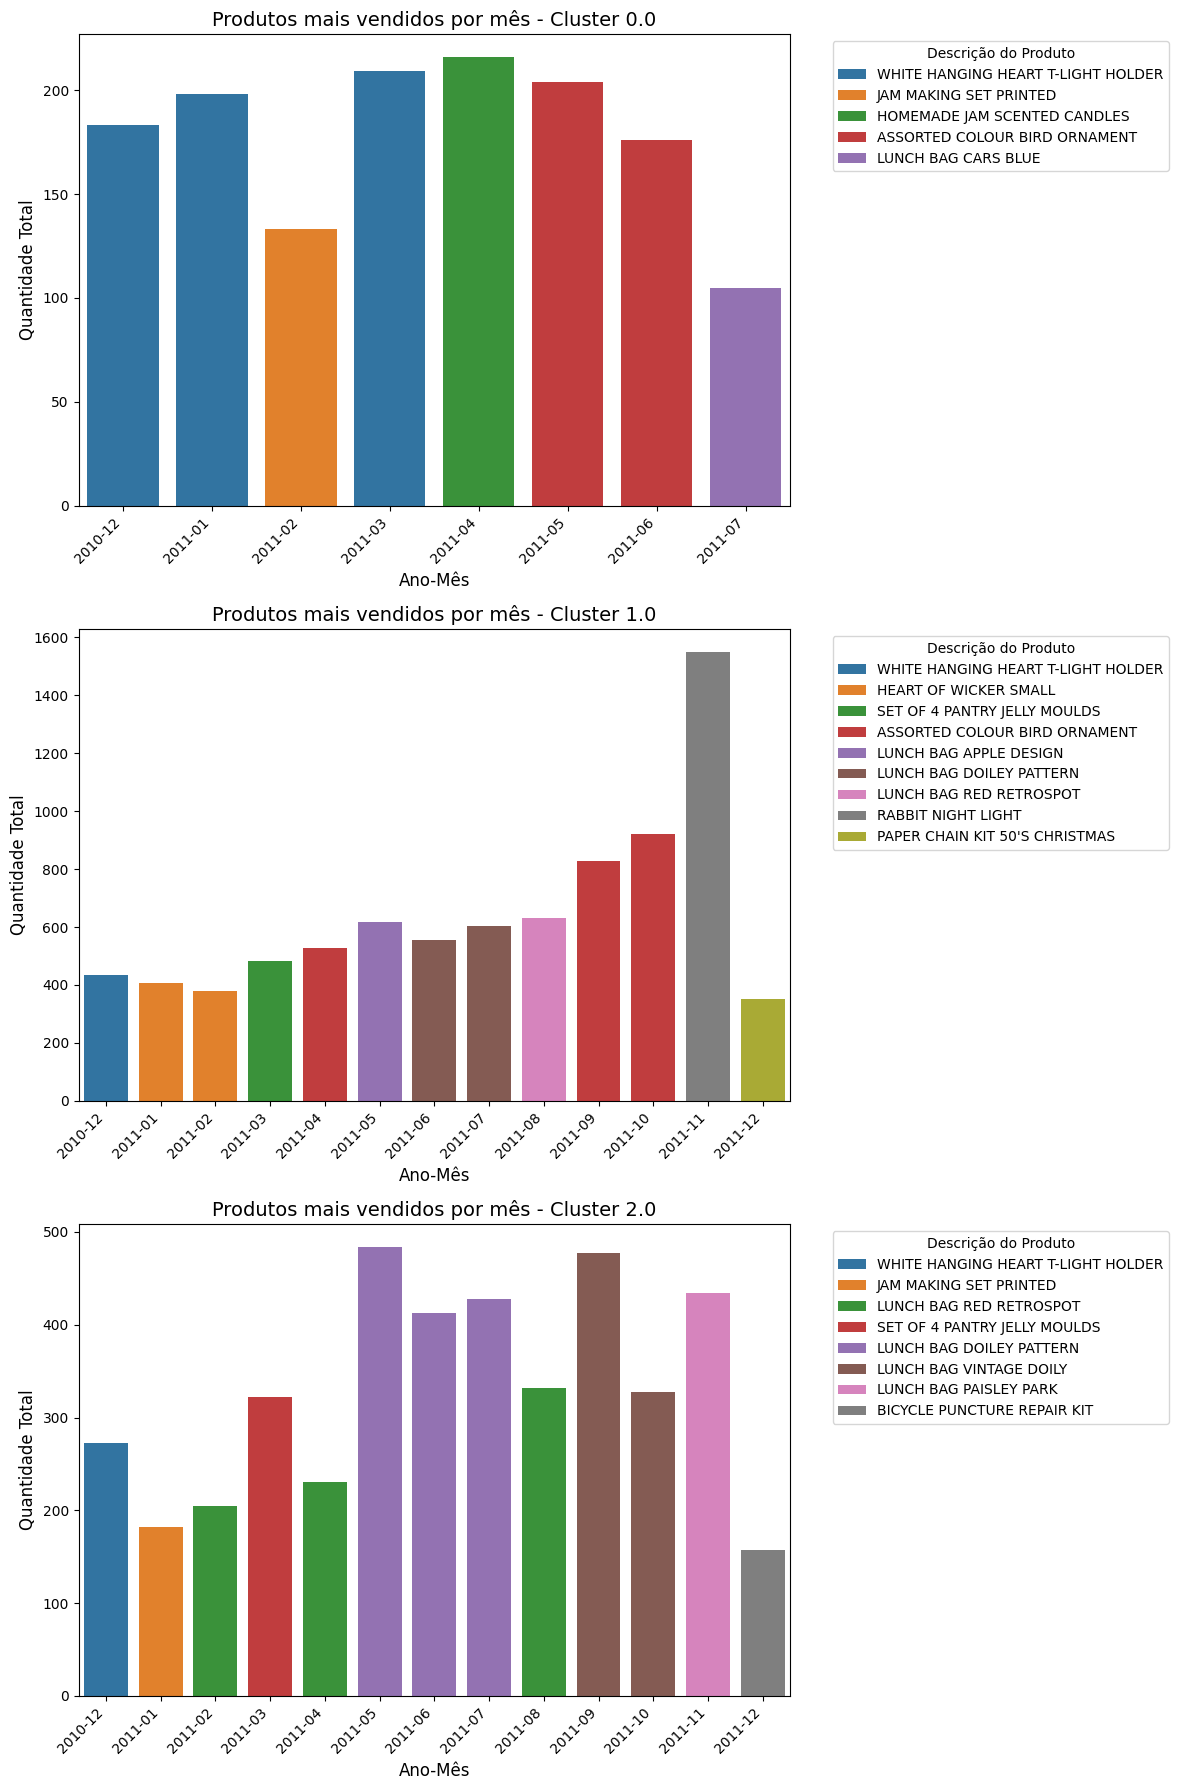

In [360]:
clusters = top_products_by_cluster['cluster'].unique()
fig, axes = plt.subplots(len(clusters), 1, figsize=(12, 6 * len(clusters)), sharex=False)


if len(clusters) == 1:
    axes = [axes]
for i, cluster in enumerate(clusters):
    ax = axes[i]
    cluster_data = top_products_by_cluster[top_products_by_cluster['cluster'] == cluster]
    
    sns.barplot(
        data=cluster_data,
        x='month',
        y='total_quantity',
        hue='description',
        ax=ax,
        dodge=False
    )
    
    
    ax.set_xticklabels(cluster_data['month'], rotation=45, ha='right')
    ax.set_title(f'Produtos mais vendidos por mês - Cluster {cluster}', fontsize=14)
    ax.set_xlabel('Ano-Mês', fontsize=12)
    ax.set_ylabel('Quantidade Total', fontsize=12)
    ax.legend(title='Descrição do Produto', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

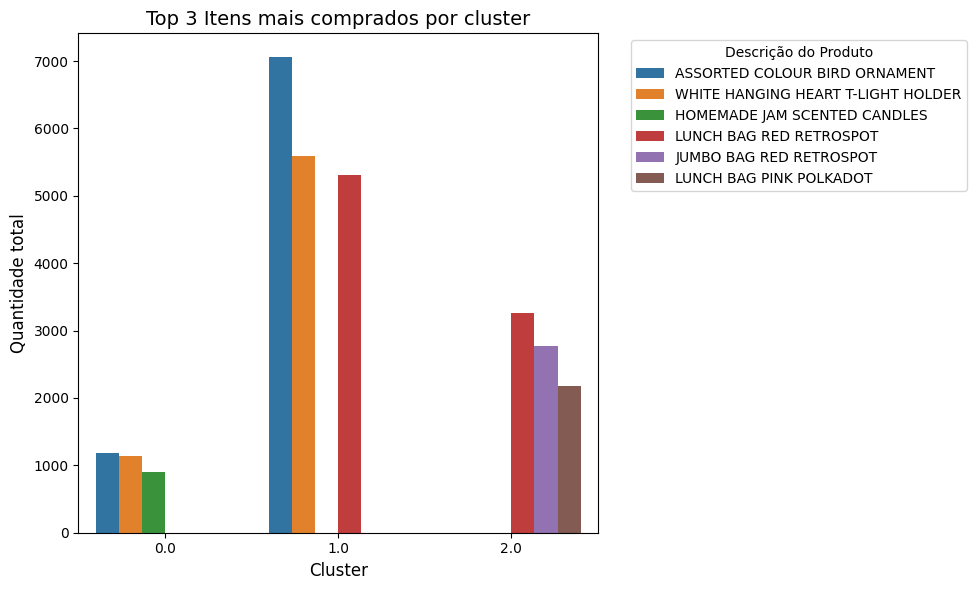

In [362]:
top_3_products_by_cluster = (
    positive_store.groupby(['cluster', 'description'])
    .agg(total_quantity=('quantity', 'sum'))
    .reset_index()
    .sort_values(by=['cluster', 'total_quantity'], ascending=[True, False])
    .groupby('cluster')
    .head(3)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_3_products_by_cluster,
    x='cluster',
    y='total_quantity',
    hue='description'
)
plt.title("Top 3 Itens mais comprados por cluster", fontsize=14)
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Quantidade total", fontsize=12)
plt.legend(title="Descrição do Produto", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [363]:
top_3_products_by_cluster = (
    positive_store.groupby(['cluster', 'description'])
    .agg(total_quantity=('quantity', 'sum'))
    .reset_index()
    .sort_values(by=['cluster', 'total_quantity'], ascending=[True, False])
    .groupby('cluster')
    .head(3)
)

print(top_3_products_by_cluster)

      cluster                         description  total_quantity
123       0.0       ASSORTED COLOUR BIRD ORNAMENT            1190
2115      0.0  WHITE HANGING HEART T-LIGHT HOLDER            1142
955       0.0        HOMEMADE JAM SCENTED CANDLES             903
2357      1.0       ASSORTED COLOUR BIRD ORNAMENT            7058
4941      1.0  WHITE HANGING HEART T-LIGHT HOLDER            5588
3600      1.0             LUNCH BAG RED RETROSPOT            5302
6273      2.0             LUNCH BAG RED RETROSPOT            3263
6140      2.0             JUMBO BAG RED RETROSPOT            2765
6272      2.0             LUNCH BAG PINK POLKADOT            2181


# CLV Predictions


In [369]:
cutoff_date = positive_store['invoice_date'].quantile(0.7)
cutoff_date


future_store = positive_store[positive_store['invoice_date'] > cutoff_date]

future_revenue = (
    future_store.groupby('customer_id')['total_price']
    .sum()
    .reset_index()
    .rename(columns={'total_price': 'future_revenue'})
)


In [370]:
customer_behavior = customer_behavior.merge(
    future_revenue,
    on='customer_id',
    how='left'
)

customer_behavior['future_revenue'] = customer_behavior['future_revenue'].fillna(0)

In [371]:
cluster_clv = customer_behavior.groupby('cluster')['future_revenue'].mean()
cluster_clv

cluster
0      0.000000
1    247.299875
2    998.912158
Name: future_revenue, dtype: float64

In [373]:
from sklearn.model_selection import train_test_split

X = customer_behavior[['recency', 'frequency', 'monetary']]
y = customer_behavior['future_revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [378]:
from sklearn.ensemble import RandomForestRegressor

X = customer_behavior[['recency', 'frequency', 'monetary']]
y = customer_behavior['future_revenue']

model = RandomForestRegressor(random_state=42)
model.fit(X, y)

customer_behavior['predicted_clv'] = model.predict(X)


In [ ]:

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [376]:
y_pred = model.predict(X_test)


In [377]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)


R² Score: 0.66335021802218


In [379]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 93.45236488456865
RMSE: 214.8496159516725
